# 02. Popularity threshold sensitivity

01에서 Head=상위 10%로 보니 플리 Head ratio가 평균 0.91에 몰렸다.
상위 10% track이 이미 playlist-mass의 대부분을 차지하므로 **정의상 예정된 결과**일 수 있다.

이번 노트북의 질문:

> **Top 1% / 5% / 10%로 좁혀도 플레이리스트들이 비슷한가, 아니면 차이가 드러나는가?**

Popularity = `n_playlists` (몇 개 플리에 포함됐는가). 연속형으로 `avg_log_n_playlists`, `avg_pct_rank`도 본다.

선행: `python -m src.aggregate --composition-only`

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

HERE = Path.cwd()
if (HERE / "data" / "processed").exists():
    ROOT = HERE
elif (HERE.parent / "data" / "processed").exists():
    ROOT = HERE.parent
else:
    ROOT = Path("..").resolve()
PROCESSED = ROOT / "data" / "processed"

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

RATIO_COLS = ["top_1pct_ratio", "top_5pct_ratio", "top_10pct_ratio"]
RATIO_LABELS = ["Top 1%", "Top 5%", "Top 10%"]

In [2]:
summary_path = PROCESSED / "frequency_summary.json"
comp_path = PROCESSED / "playlist_composition.parquet"
if not summary_path.exists() or not comp_path.exists():
    raise FileNotFoundError("집계가 없습니다. `python -m src.aggregate --composition-only` 를 먼저 실행하세요.")

summary = json.loads(summary_path.read_text(encoding="utf-8"))
comp = pd.read_parquet(comp_path)
playlists = pd.read_parquet(PROCESSED / "playlist_meta.parquet")

missing = [c for c in RATIO_COLS + ["avg_log_n_playlists", "avg_pct_rank"] if c not in comp.columns]
if missing:
    raise ValueError(
        f"composition에 {missing} 이(가) 없습니다. "
        "`python -m src.aggregate --composition-only` 로 다시 집계하세요."
    )

print(f"playlists={summary['n_playlists']:,}  popularity={summary.get('popularity_definition')}")
print("global track playlist-mass share:")
t = summary["track"]
for k in ["top_1pct_playlist_mass_share", "top_5pct_playlist_mass_share", "top_10pct_playlist_mass_share"]:
    if k in t:
        print(f"  {k}: {t[k]:.3f}")

playlists=1,000,000  popularity=n_playlists
global track playlist-mass share:
  top_1pct_playlist_mass_share: 0.667
  top_5pct_playlist_mass_share: 0.853
  top_10pct_playlist_mass_share: 0.908


## 1. Top-k ratio 분포 비교

각 기준에서 mean / median / p10~p90을 보고, 히스토그램으로 몰림 정도를 확인한다.

In [3]:
def describe_ratio(s: pd.Series) -> dict:
    s = s.dropna()
    return {
        "mean": s.mean(),
        "std": s.std(),
        "p10": s.quantile(0.10),
        "p25": s.quantile(0.25),
        "p50": s.quantile(0.50),
        "p75": s.quantile(0.75),
        "p90": s.quantile(0.90),
        "iqr": s.quantile(0.75) - s.quantile(0.25),
        "p90_p10": s.quantile(0.90) - s.quantile(0.10),
    }

stats = pd.DataFrame({lab: describe_ratio(comp[col]) for lab, col in zip(RATIO_LABELS, RATIO_COLS)}).T
stats.round(3)

,mean,std,p10,p25,p50,p75,p90,iqr,p90_p10
Top 1%,0.672,0.287,0.200,0.489,0.759,0.909,0.974,0.420,0.774
Top 5%,0.855,0.211,0.565,0.814,0.943,1.000,1.000,0.186,0.435
Top 10%,0.909,0.169,0.726,0.904,0.979,1.000,1.000,0.096,0.274


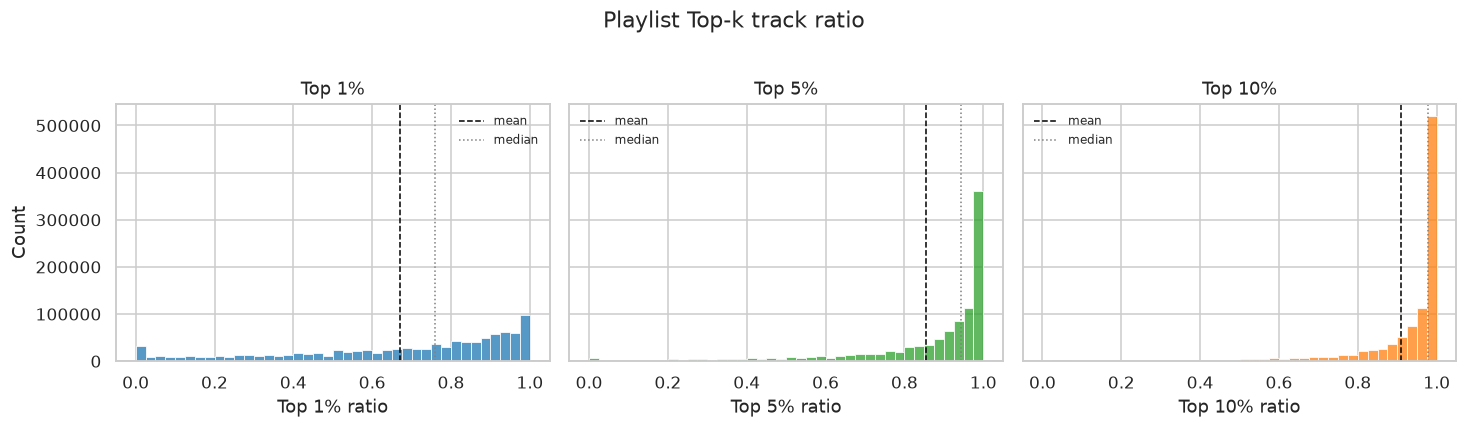

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.8), sharey=True)
colors = ["#1f77b4", "#2ca02c", "#ff7f0e"]
for ax, col, lab, color in zip(axes, RATIO_COLS, RATIO_LABELS, colors):
    sns.histplot(comp[col].dropna(), bins=40, ax=ax, color=color)
    ax.axvline(comp[col].mean(), color="black", ls="--", lw=1, label="mean")
    ax.axvline(comp[col].median(), color="gray", ls=":", lw=1, label="median")
    ax.set_xlabel(f"{lab} ratio")
    ax.set_title(lab)
    ax.legend(frameon=False, fontsize=8)
fig.suptitle("Playlist Top-k track ratio", y=1.02)
fig.tight_layout()

## 2. 연속형 popularity (컷에 덜 의존)

- `avg_log_n_playlists`: 플리 안 곡들의 log(1 + n_playlists) 평균
- `avg_pct_rank`: 전역 pct_rank 평균 (작을수록 더 인기곡 쪽)

In [5]:
cont_stats = pd.DataFrame({
    "avg_log_n_playlists": describe_ratio(comp["avg_log_n_playlists"]),
    "avg_pct_rank": describe_ratio(comp["avg_pct_rank"]),
}).T
cont_stats.round(3)

,mean,std,p10,p25,p50,p75,p90,iqr,p90_p10
avg_log_n_playlists,6.807,1.690,4.404,5.848,7.151,8.088,8.673,2.241,4.268
avg_pct_rank,0.039,0.074,0.002,0.005,0.013,0.039,0.098,0.034,0.096


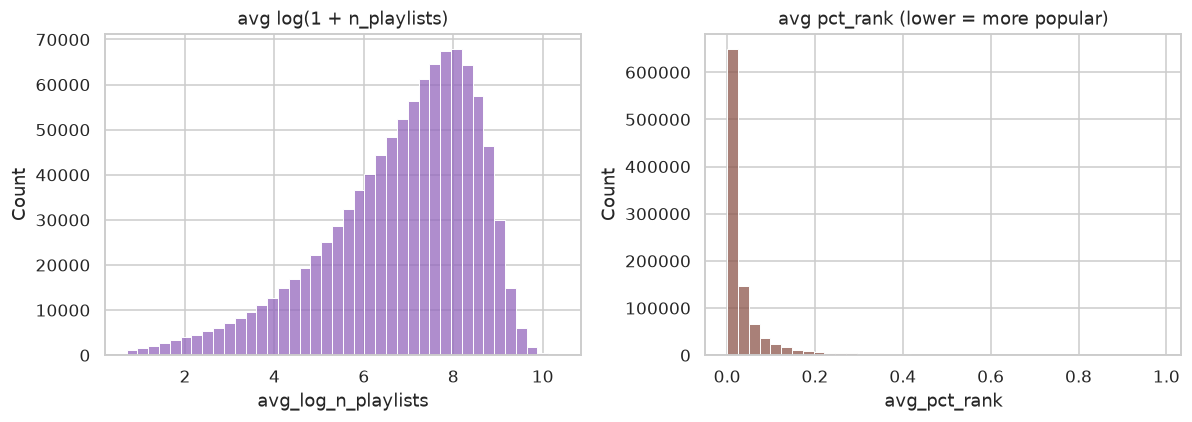

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.0))
sns.histplot(comp["avg_log_n_playlists"].dropna(), bins=40, ax=axes[0], color="#9467bd")
axes[0].set_title("avg log(1 + n_playlists)")
axes[0].set_xlabel("avg_log_n_playlists")

sns.histplot(comp["avg_pct_rank"].dropna(), bins=40, ax=axes[1], color="#8c564b")
axes[1].set_title("avg pct_rank (lower = more popular)")
axes[1].set_xlabel("avg_pct_rank")
fig.tight_layout()

## 3. (참고) Length는 평균을 바꾸나, 분산만 키우나?

짧은 플리의 ratio가 넓게 퍼지는 건 수학적으로 자연스럽다.
여기서는 **Top 1%만** 보고, length bin별 mean과 IQR을 비교한다.
차이가 크지 않으면 Length 해석은 보류한다.

In [7]:
merged = comp.merge(playlists[["pid", "num_tracks"]], on="pid", how="left")
bins = [0, 20, 50, 100, 150, 250]
labels = ["1-20", "21-50", "51-100", "101-150", "151+"]
merged["len_bin"] = pd.cut(merged["num_tracks"], bins=bins, labels=labels, right=True)

by_len = merged.groupby("len_bin", observed=True)["top_1pct_ratio"].agg(
    n="count",
    mean="mean",
    p50="median",
    p25=lambda s: s.quantile(0.25),
    p75=lambda s: s.quantile(0.75),
)
by_len["iqr"] = by_len["p75"] - by_len["p25"]
by_len.round(3)

,n,mean,p50,p25,p75,iqr
len_bin,,,,,,
1-20,178744,0.650,0.737,0.421,0.923,0.502
21-50,333702,0.681,0.769,0.500,0.919,0.419
51-100,271072,0.685,0.772,0.519,0.911,0.392
101-150,120954,0.670,0.754,0.500,0.897,0.397
151+,95527,0.643,0.722,0.461,0.875,0.414


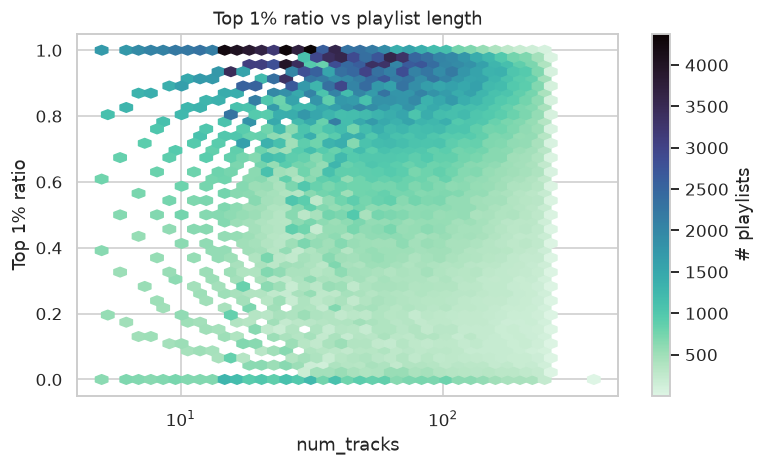

In [8]:
fig, ax = plt.subplots(figsize=(7.2, 4.4))
hb = ax.hexbin(
    merged["num_tracks"],
    merged["top_1pct_ratio"],
    gridsize=40,
    cmap="mako_r",
    mincnt=1,
    xscale="log",
)
ax.set_xlabel("num_tracks")
ax.set_ylabel("Top 1% ratio")
ax.set_title("Top 1% ratio vs playlist length")
fig.colorbar(hb, ax=ax, label="# playlists")
fig.tight_layout()

## 이 노트북에서 결정할 것

| 결과 | 다음 |
|---|---|
| Top 1%로 좁혀도 플리들이 비슷하게 몰림 | 전역 concentration → 추천에서 전달/증폭? (경로 B) |
| Top 1%/5%에서 플리 간 차이가 큼 | Length → Followers → Edits 순으로 원인 탐색 |
| 차이는 있지만 Length bin 평균만 바뀌고 IQR만 줄어듦 | Length는 분산 효과일 수 있음. 평균 차이를 통제한 뒤 재판단 |

판단 힌트: `p90 - p10` / IQR이 Top 1%에서도 작으면 **이질성이 약하다**. 크면 **이질성이 살아난 것**.

Followers / Title / 추천 모델은 이 결정 이후에만.